In [1]:
import pandas as pd

# Load your crop dataset
cy = pd.read_csv("crop_dataset.csv")
cy

,state,district,crop,crop_year,season,temperature,rainfall,area,production,yield
0,ANDAMAN AND NICOBAR ISLAND,NICOBARS,Arecanut,2007,Kharif,23.250000,1100.72570,2439.6,3415.0,1.40
1,ANDAMAN AND NICOBAR ISLAND,NICOBARS,Arecanut,2007,Rabi,23.250000,1100.72570,1626.4,2277.0,1.40
2,ANDAMAN AND NICOBAR ISLAND,NICOBARS,Arecanut,2008,Autumn,22.756923,405.56560,4147.0,3060.0,0.74
3,ANDAMAN AND NICOBAR ISLAND,NICOBARS,Arecanut,2008,Summer,22.756923,405.56560,4147.0,2660.0,0.64
4,ANDAMAN AND NICOBAR ISLAND,NICOBARS,Arecanut,2009,Autumn,23.503077,1060.89450,4153.0,3120.0,0.75
...,...,...,...,...,...,...,...,...,...,...
345322,WEST BENGAL,PURULIA,Wheat,2015,Rabi,23.865385,932.75670,855.0,1241.0,1.45
345323,WEST BENGAL,PURULIA,Wheat,2016,Rabi,24.496154,458.79095,1366.0,2415.0,1.77
345324,WEST BENGAL,PURULIA,Wheat,2017,Rabi,23.740000,1035.74290,1052.0,2145.0,2.04
345325,WEST BENGAL,PURULIA,Wheat,2018,Rabi,23.967692,2068.75515,833.0,2114.0,2.54


In [2]:
print(cy.shape)

(345327, 10)


In [3]:
cy.columns = cy.columns.str.strip().str.lower()

In [4]:
cy = cy.drop('production', axis=1)

In [5]:
cy.isnull().sum()

state          0
district       0
crop           0
crop_year      0
season         0
temperature    0
rainfall       0
area           0
yield          0
dtype: int64

In [6]:
# Count duplicate rows
duplicate_count = cy.duplicated().sum()
print("Duplicate rows:", duplicate_count)

Duplicate rows: 0


In [7]:
lower = cy["yield"].quantile(0.02)
upper = cy["yield"].quantile(0.98)
cy = cy[(cy["yield"] >= lower) & (cy["yield"] <= upper)]

In [8]:
X = cy.drop(['yield'], axis=1)
y = cy['yield']

In [9]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.compose import ColumnTransformer

# Numerical
num_cols = ['temperature', 'rainfall', 'area']

# Low-cardinality (good for OneHot)
low_cat = ['season', 'crop']

# High-cardinality (better with Ordinal)
high_cat = ['state', 'district']

preprocessor = ColumnTransformer([
    ('num', StandardScaler(), num_cols),
    ('low_cat', OneHotEncoder(handle_unknown='ignore'), low_cat),
    ('high_cat', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1), high_cat)
])

In [10]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [11]:
import numpy as np
weights = 1 / np.sqrt(y_train + 1)

In [12]:
# Fit and transform training data
X_train_trans = preprocessor.fit_transform(X_train)
X_test_trans = preprocessor.transform(X_test)


In [13]:
from xgboost import XGBRegressor

model=XGBRegressor(
    objective='reg:squarederror',
    n_estimators=3000,
    learning_rate=0.02,
    max_depth=10,
    min_child_weight=3,
    subsample=0.9,
    colsample_bytree=0.9,
    gamma=0.1,
    reg_alpha=0.3,
    reg_lambda=1.5,
    tree_method='hist',
    random_state=42

    )
    



In [14]:
model.fit(X_train_trans, y_train, sample_weight=weights)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.9, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=0.1, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.02, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=10,
             max_leaves=None, min_child_weight=3, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=3000,
             n_jobs=None, num_parallel_tree=None, ...)

In [15]:
y_pred = model.predict(X_test_trans)

In [16]:
y_test_actual = y_test
y_pred_actual = y_pred

In [17]:
import numpy as np
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error

mae = mean_absolute_error(y_test_actual, y_pred_actual)
r2 = r2_score(y_test_actual, y_pred_actual)
rmse = np.sqrt(mean_squared_error(y_test_actual, y_pred_actual))

print("MAE:", mae)
print("R2:", r2)
print("RMSE:", rmse)

MAE: 0.6579072850524872
R2: 0.9439718243928158
RMSE: 1.9307698123817567


In [18]:
input_data = pd.DataFrame([{
    'temperature': 28,
    'rainfall': 120,
    'area': 15,
    'crop_year': 2025,
    'season': 'Kharif',
    'crop': 'Rice',
    'state': 'Karnataka',
    'district': 'Davangere'
}])

In [19]:
# Transform input using saved preprocessor
input_transformed = preprocessor.transform(input_data)

# Predict
prediction = model.predict(input_transformed)

print("Predicted Yield:", prediction[0])

Predicted Yield: 2.0950553


In [20]:
import joblib

# Save everything together
joblib.dump({
    "model": model,
    "preprocessor": preprocessor
}, "crop_yield_model.pkl")

print("Model saved successfully!")

Model saved successfully!


In [21]:
import joblib

# Load saved file
data = joblib.load("crop_yield_model.pkl")

# Extract model and preprocessor
model = data["model"]
preprocessor = data["preprocessor"]

print("Model loaded successfully!")

Model loaded successfully!


In [22]:
import pandas as pd

# Example user input
input_data = pd.DataFrame([{
    'temperature': 28,
    'rainfall': 120,
    'area': 15,
    'season': 'Kharif',
    'crop': 'Rice',
    'state': 'Karnataka',
    'district': 'Davangere'
}])

# Transform input using saved preprocessor
input_transformed = preprocessor.transform(input_data)

# Predict
prediction = model.predict(input_transformed)

print("Predicted Yield:", prediction[0])

Predicted Yield: 2.0950553


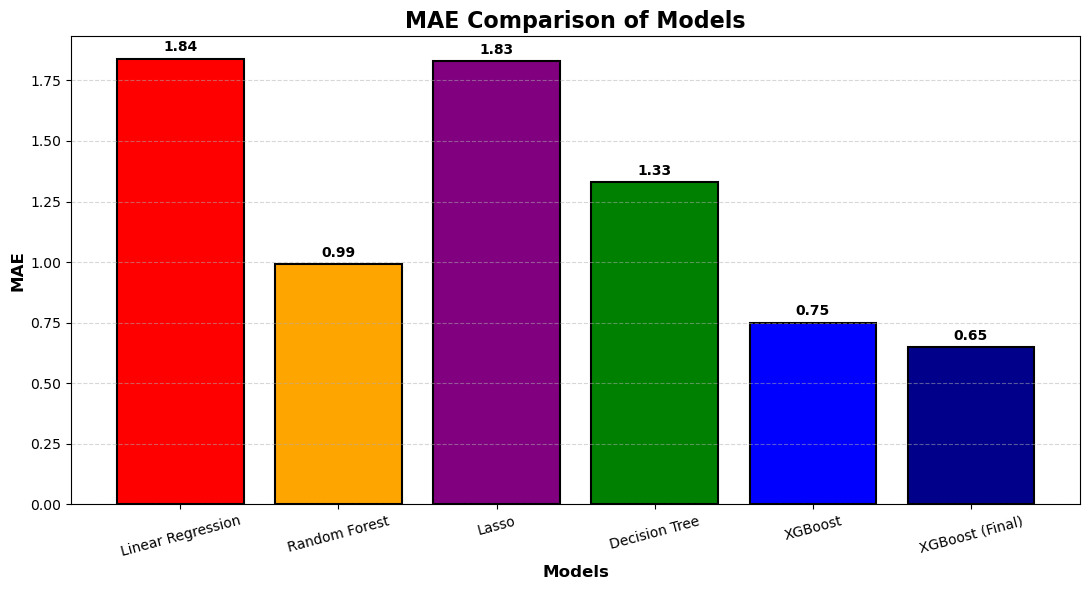

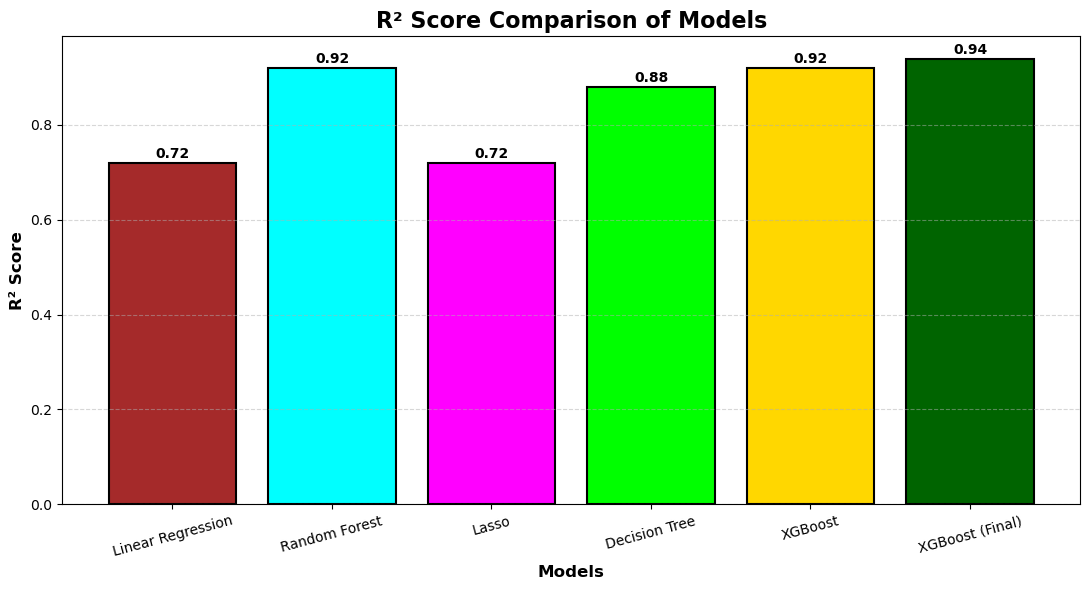

In [4]:
import matplotlib.pyplot as plt
import pandas as pd

# =========================
# MODEL PERFORMANCE DATA
# =========================
models = [
    "Linear Regression",
    "Random Forest",
    "Lasso",
    "Decision Tree",
    "XGBoost",
    "XGBoost (Final)"
]

# ✅ Corrected MAE
mae_scores = [1.84, 0.99, 1.83, 1.33, 0.75, 0.65]

r2_scores = [0.72, 0.92, 0.72, 0.88, 0.92, 0.94]

# =========================
# CREATE DATAFRAME
# =========================
df = pd.DataFrame({
    "Model": models,
    "MAE": mae_scores,
    "R2 Score": r2_scores
})

# =========================
# COLORS
# =========================
colors_mae = [
    "red",
    "orange",
    "purple",
    "green",
    "blue",
    "darkblue"
]

colors_r2 = [
    "brown",
    "cyan",
    "magenta",
    "lime",
    "gold",
    "darkgreen"
]

# =========================
# BAR GRAPH FOR MAE
# =========================
plt.figure(figsize=(11, 6))

bars = plt.bar(
    df["Model"],
    df["MAE"],
    color=colors_mae,
    edgecolor='black',
    linewidth=1.5
)

plt.xlabel("Models", fontsize=12, fontweight='bold')
plt.ylabel("MAE", fontsize=12, fontweight='bold')
plt.title("MAE Comparison of Models", fontsize=16, fontweight='bold')

plt.xticks(rotation=15, fontsize=10)
plt.yticks(fontsize=10)

# Add values on bars
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.03,
        f"{height:.2f}",
        ha='center',
        fontsize=10,
        fontweight='bold'
    )

plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

# =========================
# BAR GRAPH FOR R2 SCORE
# =========================
plt.figure(figsize=(11, 6))

bars = plt.bar(
    df["Model"],
    df["R2 Score"],
    color=colors_r2,
    edgecolor='black',
    linewidth=1.5
)

plt.xlabel("Models", fontsize=12, fontweight='bold')
plt.ylabel("R² Score", fontsize=12, fontweight='bold')
plt.title("R² Score Comparison of Models", fontsize=16, fontweight='bold')

plt.xticks(rotation=15, fontsize=10)
plt.yticks(fontsize=10)

# Add values on bars
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.01,
        f"{height:.2f}",
        ha='center',
        fontsize=10,
        fontweight='bold'
    )

plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()